Implementing Elastic Weight Consolidation

Confirming and Visualizing the interference

In [49]:
import torch
import numpy as np
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset

Setting up Hyperparameters

In [50]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
learning_rate = 1e-3
batch_size = 64
epochs_per_task = 3
tasks = [(0, 1), (2, 3), (4, 5), (6, 7), (8, 9)]

In [51]:
print(f"Using device: {device}")

Using device: cpu


Dataset Loading and splitting

In [52]:
mnist_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

In [53]:
train_dataset = datasets.MNIST(root='/home/bukunmi/ml-journey/datasets/data', train=True, download=True, transform=mnist_transform)
test_dataset = datasets.MNIST(root='/home/bukunmi/ml-journey/datasets/data', train=False, download=True, transform=mnist_transform)

In [54]:
# Filter by Digits

def filter_by_digits(dataset, digits):
    targets = torch.as_tensor(dataset.targets)
    digit_mask = torch.isin(targets, torch.tensor(digits))
    indices = torch.where(digit_mask)[0].tolist()
    return Subset(dataset, indices)

In [55]:
# Get split MNIST datasets for each task
def get_split_mnist_datasets(tasks_digits):
    train_subset = filter_by_digits(train_dataset, tasks_digits)
    test_subset = filter_by_digits(test_dataset, tasks_digits)
    train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_subset, batch_size=batch_size, shuffle=False)
    return train_loader, test_loader

Defining the MNIST MLP

In [56]:
class MNISTMLP(nn.Module):
    def __init__(self, input_size=28*28, hidden_size=400, output_size=10):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, output_size)
        )
    
    def forward(self, x):
        return self.fc(x)

Instantiate Model, optimizer, criterion and task loaders

In [57]:
model = MNISTMLP().to(device)
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
criterion = nn.CrossEntropyLoss()

In [58]:
task_loaders = [get_split_mnist_datasets(task) for task in tasks]

Training Init

In [59]:
accuracy_history = np.zeros((len(tasks), len(tasks)))

In [60]:
# Evaluation Function
def evaluate(model, test_loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            logits = model(images)
            _, predicted = torch.max(logits, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return (correct / total) * 100 if total > 0 else 0.0


def evaluate_task_masked(model, test_loader, task_digits):
    model.eval()
    correct, total = 0, 0
    task_digits = torch.tensor(task_digits, device=device)

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            logits = model(images)
            masked_logits = logits[:, task_digits]
            predicted = task_digits[masked_logits.argmax(dim=1)]
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return (correct / total) * 100 if total > 0 else 0.0

In [61]:
# Training Loop
for train_task_idx, (train_loader, test_loader) in enumerate(task_loaders):
    print(f"\n--- Training on Task {train_task_idx + 1} -- (Digits: {tasks[train_task_idx]})")
    for epoch in range(epochs_per_task):
        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            logits = model(images)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        print(f"Epoch {epoch + 1}/{epochs_per_task} ----- Loss: {running_loss / len(train_loader):.4f}")
    print(f"--- Evaluating after Task {train_task_idx + 1} ---")
    for eval_task_idx, (_, test_loader) in enumerate(task_loaders):
        acc = evaluate(model, test_loader)
        accuracy_history[eval_task_idx, train_task_idx] = acc
        print(f"  Accuracy on Task {eval_task_idx + 1} (Digits {tasks[eval_task_idx]}): {acc:.2f}%")


--- Training on Task 1 -- (Digits: (0, 1))
Epoch 1/3 ----- Loss: 0.0381
Epoch 2/3 ----- Loss: 0.0030
Epoch 3/3 ----- Loss: 0.0020
--- Evaluating after Task 1 ---
  Accuracy on Task 1 (Digits (0, 1)): 99.62%
  Accuracy on Task 2 (Digits (2, 3)): 0.00%
  Accuracy on Task 3 (Digits (4, 5)): 0.00%
  Accuracy on Task 4 (Digits (6, 7)): 0.00%
  Accuracy on Task 5 (Digits (8, 9)): 0.00%

--- Training on Task 2 -- (Digits: (2, 3))
Epoch 1/3 ----- Loss: 0.2766
Epoch 2/3 ----- Loss: 0.0457
Epoch 3/3 ----- Loss: 0.0274
--- Evaluating after Task 2 ---
  Accuracy on Task 1 (Digits (0, 1)): 0.00%
  Accuracy on Task 2 (Digits (2, 3)): 99.41%
  Accuracy on Task 3 (Digits (4, 5)): 0.00%
  Accuracy on Task 4 (Digits (6, 7)): 0.00%
  Accuracy on Task 5 (Digits (8, 9)): 0.00%

--- Training on Task 3 -- (Digits: (4, 5))
Epoch 1/3 ----- Loss: 0.5009
Epoch 2/3 ----- Loss: 0.0154
Epoch 3/3 ----- Loss: 0.0094
--- Evaluating after Task 3 ---
  Accuracy on Task 1 (Digits (0, 1)): 0.00%
  Accuracy on Task 2 (Dig

The model is forgetting all previous knowledge.

Plotting the forgetting curve

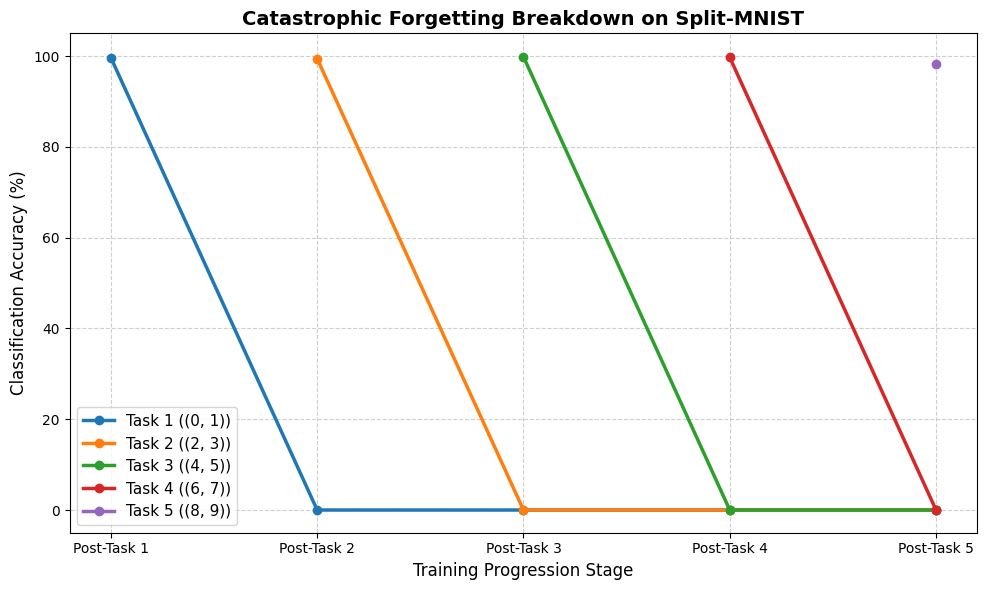

In [62]:
plt.figure(figsize=(10, 6))
x_ticks = [f"Post-Task {i+1}" for i in range(len(tasks))]

for task_idx in range(len(tasks)):
    y_values = accuracy_history[task_idx]
    plt.plot(x_ticks[task_idx:], y_values[task_idx:], marker='o', linewidth=2.5, label=f"Task {task_idx+1} ({tasks[task_idx]})")

plt.title("Catastrophic Forgetting Breakdown on Split-MNIST", fontsize=14, fontweight='bold')
plt.xlabel("Training Progression Stage", fontsize=12)
plt.ylabel("Classification Accuracy (%)", fontsize=12)
plt.ylim(-5, 105)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='lower left', fontsize=11)
plt.tight_layout()
plt.show()

Fisher Estimation

In [63]:
def estimate_fisher(model: nn.Module, data_loader, max_batches=100):
    model.eval()
    fisher = {
        name: torch.zeros_like(param) for name, param in model.named_parameters() if param.requires_grad
    }

    batches = 0
    for images, labels in data_loader:
        images, labels = images.to(device), labels.to(device)
        model.zero_grad(set_to_none=True)

        logits = model(images)
        loss = nn.functional.cross_entropy(logits, labels, reduction="sum")
        loss.backward()

        for name, param in model.named_parameters():
            if param.grad is not None: 
                fisher[name] += param.grad.detach().pow(2)
        
        batches += 1
        if batches >= max_batches:
            break
    
    for name in fisher:
        fisher[name] /= max(1, batches)
    
    return fisher

In [64]:
def snapshot_params(model: nn.Module):
    return {
        name: param.detach().clone() for name, param in model.named_parameters() if param.requires_grad
    }

In [65]:
def ewc_penalty(model: nn.Module, ewc_tasks):
    penalty = 0.0

    for old_params, fisher in ewc_tasks:
        for name, param in model.named_parameters():
            if name in fisher:
                penalty += (fisher[name] * (param - old_params[name]).pow(2)).sum()

    return penalty

In [66]:
def train_task_with_ewc(model, optimizer, criterion, train_loader, ewc_tasks, lambda_ewc, max_grad_norm=10.0):
    model.train()

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad(set_to_none=True)
        ce_loss = criterion(model(images), labels)
        penalty = torch.zeros((), device=device)

        if ewc_tasks:
            penalty = ewc_penalty(model, ewc_tasks)

        loss = ce_loss + (lambda_ewc / 2) * penalty
        
        loss.backward()
        if max_grad_norm is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
        optimizer.step()

In [67]:
def calculate_forgetting(acc_matrix):
    forgetting = []

    for task_idx in range(acc_matrix.shape[0] - 1):
        task_scores = acc_matrix[task_idx, task_idx:]
        highest_acc = np.max(task_scores)
        final_acc = acc_matrix[task_idx, -1]
        forgetting.append(highest_acc - final_acc)

    return np.mean(forgetting) if forgetting else 0.0


def calculate_final_old_task_accuracy(acc_matrix):
    return np.mean(acc_matrix[:-1, -1])

In [68]:
lambda_values = [0, 1e3, 1e4, 1e5, 1e6]
ewc_results = []

for lambda_ewc in lambda_values:
    model = MNISTMLP().to(device)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    criterion = nn.CrossEntropyLoss()

    ewc_tasks = []
    accuracy_history = np.zeros((len(tasks), len(tasks)))
    masked_accuracy_history = np.zeros((len(tasks), len(tasks)))

    for train_task_idx, (train_loader, _) in enumerate(task_loaders):
        for epoch in range(epochs_per_task):
            train_task_with_ewc(
                model,
                optimizer,
                criterion,
                train_loader,
                ewc_tasks,
                lambda_ewc
            )

        fisher = estimate_fisher(model, train_loader)
        old_params = snapshot_params(model)
        ewc_tasks.append((old_params, fisher))

        for eval_task_idx, (_, test_loader) in enumerate(task_loaders):
            acc = evaluate(model, test_loader)
            accuracy_history[eval_task_idx, train_task_idx] = acc
            masked_acc = evaluate_task_masked(model, test_loader, tasks[eval_task_idx])
            masked_accuracy_history[eval_task_idx, train_task_idx] = masked_acc

    ewc_results.append({
        "lambda": lambda_ewc,
        "accuracy_history": accuracy_history,
        "masked_accuracy_history": masked_accuracy_history,
        "forgetting": calculate_forgetting(accuracy_history),
        "final_old_acc": calculate_final_old_task_accuracy(accuracy_history),
        "masked_forgetting": calculate_forgetting(masked_accuracy_history),
        "masked_final_old_acc": calculate_final_old_task_accuracy(masked_accuracy_history),
    })

for result in ewc_results:
    print(
        f"lambda={result['lambda']:g}: "
        f"class_old={result['final_old_acc']:.2f}, "
        f"class_forgetting={result['forgetting']:.2f}, "
        f"masked_old={result['masked_final_old_acc']:.2f}, "
        f"masked_forgetting={result['masked_forgetting']:.2f}"
    )

lambda=0: class_old=0.00, class_forgetting=99.70, masked_old=60.91, masked_forgetting=38.78
lambda=1000: class_old=0.04, class_forgetting=99.70, masked_old=94.41, masked_forgetting=5.34
lambda=10000: class_old=0.05, class_forgetting=99.69, masked_old=99.02, masked_forgetting=0.75
lambda=100000: class_old=0.00, class_forgetting=99.72, masked_old=99.15, masked_forgetting=0.58
lambda=1e+06: class_old=0.04, class_forgetting=99.15, masked_old=99.13, masked_forgetting=0.07


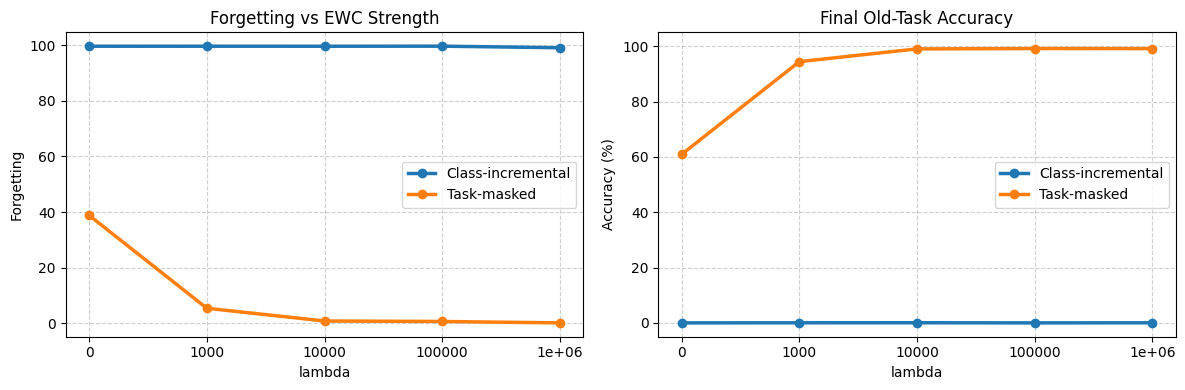

In [69]:
lambda_labels = [f"{result['lambda']:g}" for result in ewc_results]
class_forgetting = [result["forgetting"] for result in ewc_results]
masked_forgetting = [result["masked_forgetting"] for result in ewc_results]
class_old_acc = [result["final_old_acc"] for result in ewc_results]
masked_old_acc = [result["masked_final_old_acc"] for result in ewc_results]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(lambda_labels, class_forgetting, marker="o", linewidth=2.5, label="Class-incremental")
axes[0].plot(lambda_labels, masked_forgetting, marker="o", linewidth=2.5, label="Task-masked")
axes[0].set_title("Forgetting vs EWC Strength")
axes[0].set_xlabel("lambda")
axes[0].set_ylabel("Forgetting")
axes[0].grid(True, linestyle="--", alpha=0.6)
axes[0].legend()

axes[1].plot(lambda_labels, class_old_acc, marker="o", linewidth=2.5, label="Class-incremental")
axes[1].plot(lambda_labels, masked_old_acc, marker="o", linewidth=2.5, label="Task-masked")
axes[1].set_title("Final Old-Task Accuracy")
axes[1].set_xlabel("lambda")
axes[1].set_ylabel("Accuracy (%)")
axes[1].set_ylim(-5, 105)
axes[1].grid(True, linestyle="--", alpha=0.6)
axes[1].legend()

plt.tight_layout()
plt.show()